# ICS 2405: Knowledge-Based Systems

### linear regression and errors:
> linear regression is a name for drawing a straight line(of best fit) through a set of data point


#### no flat earth: why we need the slope  
> the idea of drawing a line through the dots gets a
general idea across, but it doesn’t give us a reproducible way of specifying or completing
the task - at best, it gives us a line of best fit.  
> but which line is best under that criteria?


### straight lines:

#### context:   
working w/ lines of the form, $y=c$.  
> you can think
about moving the line like raising or lowering an olympic high-jump bar: it stays parallel
to the ground. if I start sliding the line up and down, I’m going to start far away from all
the points, move close to some points, slide onwards to a great, just-right middle ground,
move close to other points, and finally end up far away from everything. yes, the idea of a
happy medium—too hot, too cold, and just right—applies here

### how it works:
  
see below:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def axis_helper(ax, lims):
    'clean up axes'
    ax.set_xlim(lims); ax.set_xticks([])
    ax.set_ylim(lims); ax.set_yticks([])
    ax.set_aspect('equal')

In [3]:
# our data is very simple: two (x, y) points
D = np.array([[3, 5], 
              [4, 2]])
# we'll take x as our "input" and y as our "output"
x, y = D[:, 0], D[:, 1]

# plot/graphing of this:
let’s graph what happens as we move a horizontal line up through different
possible values. We’ll call these values our predicted values. you can imagine each raised bar
as being a possible set of predictions for our example data points. along the way, we’ll also
keep track of what our error values are. the errors are the differences between the
horizontal line and the data points. we’ll also calculate a few values from the errors: the
sum of errors, the sum of squares of the errors (sse), and the square root of the
sum of squared errors

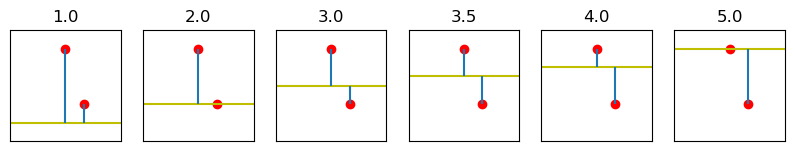

In [4]:
horizontal_lines = np.array([1, 2, 3, 3.5, 4, 5])
results = []
fig, axes = plt.subplots(1, 6, figsize=(10, 5))
for h_line, ax in zip(horizontal_lines, axes.flat):
    # styling
    axis_helper(ax, (0, 6))
    ax.set_title(str(h_line))
    # plot the data
    ax.plot(x, y, 'ro')
    # plot the prediction line
    ax.axhline(h_line, color='y') # ax coords; defaults to 100%
    # plot the errors
    # the horizontal line *is* our prediction; renaming for clarity
    predictions = h_line
    ax.vlines(x, predictions, y)
    # calculate the error amounts and their sum of squares
    errors = y - predictions
    sse = np.dot(errors, errors)
    # put together some results in a tuple
    results.append((predictions, errors, errors.sum(), sse, np.sqrt(sse)))

### sliding:
we start very far away from one point and not too far from another. as we slide the bar
up, we hit a nice middle ground between the points. yet we keep sliding the bar; we
end up on the top point, fairly far away from the bottom point. perhaps the ideal tradeoff
is somewhere in the middle

In [5]:
col_labels = "Prediction", "Errors", "Sum", "SSE", "Distance"
display(pd.DataFrame.from_records(results, columns=col_labels, index="Prediction"))

,Errors,Sum,SSE,Distance
Prediction,,,,
1.0,"[4.0, 1.0]",5.0,17.0,4.123106
2.0,"[3.0, 0.0]",3.0,9.0,3.000000
3.0,"[2.0, -1.0]",1.0,5.0,2.236068
3.5,"[1.5, -1.5]",0.0,4.5,2.121320
4.0,"[1.0, -2.0]",-1.0,5.0,2.236068
5.0,"[0.0, -3.0]",-3.0,9.0,3.000000


the table includes the raw errors that can be positive or negative—we might over- or
underestimate. the sums of those raw errors don’t do a great job evaluating the lines.
Errors in the opposite directions, such as [2, −1], give us a total of 1. in terms of our
overall prediction ability, we don’t want these errors to cancel out. one of the best ways to
address that is to use a total distance; that means we want something like √(prediction − actual)2. the sse
column is the sum of squared errors which gets us most of the way towards calculating
distances. all that’s left is to take a square root. the line that is best, under the rules so far,
is the horizontal line at the mean of the points based on their vertical component

### tilting the field:
> $y = mx + b$
>

what happens if we keep the restriction of drawing straight lines but remove the
restriction of making them horizontal? 

if the cluster of dots that you drew had an overall growth or descent, like a
plane taking off or landing, a sloped line can do better than a flat, horizontal runway.


In [6]:
def process(D, model, ax):
    # make some useful abbreviations/names
    # y is our "actual"
    x, y = D[:, 0], D[:, 1]
    m, b = model
    # styling
    axis_helper(ax, (0, 8))
    # plot the data
    ax.plot(x, y, 'ro')
    # plot the prediction line
    helper_xs = np.array([0, 8])
    helper_line = m * helper_xs + b
    ax.plot(helper_xs, helper_line, color='y')
    # plot the errors
    predictions = m * x + b
    ax.vlines(x, predictions, y)
    # calculate error amounts
    errors = y - predictions
    # tuple up the results
    sse = np.dot(errors, errors)
    return (errors, errors.sum(), sse, np.sqrt(sse))

#### prediction lines

,Raw Errors,Sum,SSE,TotDist
0,"[2, -2]",0,8,2.828427
1,"[1, -3]",-2,10,3.162278
2,"[0, -4]",-4,16,4.000000
3,"[0, -2]",-2,4,2.000000
4,"[0, 0]",0,0,0.000000


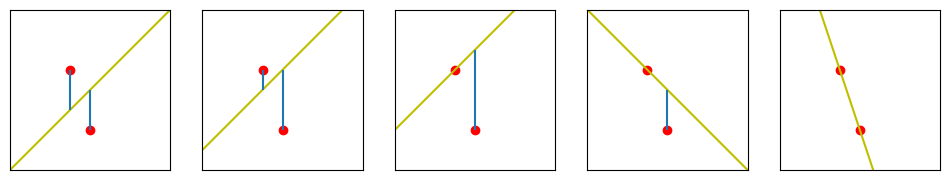

In [7]:
# our data is very simple: two (x, y) points
D = np.array([[3, 5],
[4, 2]])
# m b --> predictions = mx + b
lines_mb = np.array([[ 1, 0],
[ 1, 1],
[ 1, 2],
[-1, 8],
[-3, 14]])
col_labels = ("Raw Errors", "Sum", "SSE", "TotDist")
results = []
# note: plotting occurs in process()
fig, axes = plt.subplots(1, 5, figsize=(12, 6))
records = [process(D, mod, ax) for mod,ax in zip(lines_mb, axes.flat)]
df = pd.DataFrame.from_records(records, columns=col_labels)
display(df)

we have a progression in calculating our measure of success:
```python
predicted = m*x + b
error = (m*x + b) - actual = predicted - actual
SSE = sum(errors**2) = sum(((m*x+b) - actual)**2 for x,actual in data)
total_distance = sqrt(SSE)
```

the last line precisely intersects with both data points. Its predictions are 100% correct;
the vertical distances are zero.

### linear regresssion: putting it together
instead of a single slope m, we now have to deal with a slope for each of our feature; but we’re going to
shift away from using m and use the term weights to describe the contribution of each
feature

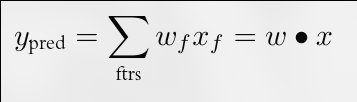

In [8]:
from IPython.display import Image
image_path = './swappy-20251118-164439.png'
Image(filename=image_path)

In [9]:
from sklearn import (model_selection as skms, linear_model, datasets, metrics)


diabetes = datasets.load_diabetes()
tts = skms.train_test_split(diabetes.data, diabetes.target, test_size=.25)

(diabetes_train_ftrs, diabetes_test_ftrs, diabetes_train_tgt, diabetes_test_tgt) = tts


lr = linear_model.LinearRegression()
fit = lr.fit(diabetes_train_ftrs, diabetes_train_tgt)
preds = fit.predict(diabetes_test_ftrs)
# evaluate our predictions against the unseen testing targets
metrics.mean_squared_error(diabetes_test_tgt, preds)

2909.3286887184668

#### optimization: picking the best answer:
picking the best line means picking the best values for $m$ and $b$ or for the $weights$.

four strategies we can adopt - for picking the best answer:
1. **random guess**: try lots of possibilities at random, take the best one.
2. **random step**: try one line—pick an m and a b—at random, make several random
adjustments, pick the adjustment that helps the most. repeat.
3. **smart step**: try one line at random, see how it does, adjust it in some smart way.
repeat.
4. **calculated shortcut**: use fancy mathematics to prove that if fact a, fact b, and fact
c are all true, then the one line to rule them all must be the best. plug in some
numbers and use the one line to rule them all.

##### random guess:

In [10]:
tgt = np.array([3, 5, 8, 10, 12, 15])

In [11]:
# random guesses with some constraints
num_guesses = 10
results = []
for g in range(num_guesses):
    guess = np.random.uniform(low=tgt.min(), high=tgt.max())
    total_dist = np.sum((tgt - guess)**2)
    results.append((total_dist, guess))
best_guess = sorted(results)[0][1]
best_guess

9.090016996823591

##### random step
> starts with a single random guess, but then takes a random step up or down. if
that step is an improvement, we keep it. otherwise, we go back to where we were

In [12]:
# use a random choice to take a hypothetical
# step up or down: follow it, if it is an improvement
num_steps = 100
step_size = .05
best_guess = np.random.uniform(low=tgt.min(), high=tgt.max())
best_dist = np.sum((tgt - best_guess)**2)
for s in range(num_steps):
    new_guess = best_guess + (np.random.choice([+1, -1]) * step_size)
    new_dist = np.sum((tgt - new_guess)**2)
    if new_dist < best_dist:
        best_guess, best_dist = new_guess, new_dist
print(best_guess)

6.405456618408049


we start with a single guess and then try to improve it by random stepping. i we take
enough steps and those steps are individually small enough, we should be able to find our
way to a solid answer.

##### smart step:

In [13]:
# hypothetically take both steps (up and down)
# choose the better of the two
# if it is an improvement, follow that step

num_steps = 1000
step_size = .02
best_guess = np.random.uniform(low=tgt.min(), high=tgt.max())
best_dist = np.sum((tgt - best_guess)**2)
print("start:", best_guess)
for s in range(num_steps):
    # np.newaxis is needed to align the minus
    guesses = best_guess + (np.array([-1, 1]) * step_size)
    dists = np.sum((tgt[:,np.newaxis] - guesses)**2, axis=0)
    better_idx = np.argmin(dists)
    if dists[better_idx] > best_dist:
        break
    best_guess = guesses[better_idx]
    best_dist = dists[better_idx]
print(" end:", best_guess)

start: 7.253339122037704
 end: 8.833339122037671


##### calculated shortcut
> eg get the mean

In [14]:
print("mean:", np.mean(tgt))

mean: 8.833333333333334


### evaluation of regressors:
> based on resource utilization, learning performance and using root means squared methods


#### learning performance:


In [16]:
# stand-alone code
from sklearn import (datasets, neighbors, model_selection as skms, linear_model, metrics)

diabetes = datasets.load_diabetes()
tts = skms.train_test_split(diabetes.data, diabetes.target, test_size=.25)

(diabetes_train, diabetes_test, diabetes_train_tgt, diabetes_test_tgt) = tts

models = {'kNN': neighbors.KNeighborsRegressor(n_neighbors=3), 'linreg' : linear_model.LinearRegression()}
for name, model in models.items(): 
    fit = model.fit(diabetes_train, diabetes_train_tgt)
    preds = fit.predict(diabetes_test)
    score = np.sqrt(metrics.mean_squared_error(diabetes_test_tgt, preds))
    print("{:>6s} : {:0.2f}".format(name,score))

   kNN : 70.78
linreg : 54.75
